In [1]:
import pandas as pd

In [5]:
weather = pd.read_csv('local_weather.csv',index_col='DATE')
weather

,STATION,NAME,ACMH,ACSH,AWND,DAPR,FMTM,FRGT,MDPR,PGTM,...,WT01,WT02,WT03,WT04,WT05,WT07,WT08,WT09,WT16,WT18
DATE,,,,,,,,,,,,,,,,,,,,,
1960-01-01,USW00023230,"OAKLAND INTERNATIONAL AIRPORT, CA US",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1960-01-02,USW00023230,"OAKLAND INTERNATIONAL AIRPORT, CA US",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN
1960-01-03,USW00023230,"OAKLAND INTERNATIONAL AIRPORT, CA US",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1960-01-04,USW00023230,"OAKLAND INTERNATIONAL AIRPORT, CA US",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1960-01-05,USW00023230,"OAKLAND INTERNATIONAL AIRPORT, CA US",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-01-24,USW00023230,"OAKLAND INTERNATIONAL AIRPORT, CA US",NaN,NaN,4.47,NaN,NaN,NaN,NaN,NaN,...,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN
2022-01-25,USW00023230,"OAKLAND INTERNATIONAL AIRPORT, CA US",NaN,NaN,4.70,NaN,NaN,NaN,NaN,NaN,...,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN
2022-01-26,USW00023230,"OAKLAND INTERNATIONAL AIRPORT, CA US",NaN,NaN,2.68,NaN,NaN,NaN,NaN,NaN,...,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN


In [10]:
weather.apply(pd.isnull).sum()/weather.shape[0]

STATION    0.000000
NAME       0.000000
ACMH       0.653360
ACSH       0.653360
AWND       0.522451
DAPR       0.999525
FMTM       0.870099
FRGT       0.999881
MDPR       0.999525
PGTM       0.495106
PRCP       0.016668
SNOW       0.324990
SNWD       0.317634
TAVG       0.879174
TMAX       0.000534
TMIN       0.000593
TSUN       0.931728
WDF1       0.653360
WDF2       0.522392
WDF5       0.527552
WDFG       0.746901
WSF1       0.653360
WSF2       0.522332
WSF5       0.527552
WSFG       0.746901
WT01       0.779939
WT02       0.980248
WT03       0.992941
WT04       0.999763
WT05       0.998339
WT07       0.999881
WT08       0.810368
WT09       0.999881
WT16       0.884038
WT18       0.999822
dtype: float64

In [11]:
core_weather = weather[['PRCP','SNOW','SNWD','TMAX','TMIN']].copy()

In [12]:
core_weather.columns = ['precip','snow','snow_depth','temp_max','temp_min']
core_weather

,precip,snow,snow_depth,temp_max,temp_min
DATE,,,,,
1960-01-01,0.0,0.0,0.0,49.0,30.0
1960-01-02,0.0,0.0,0.0,49.0,29.0
1960-01-03,0.0,0.0,0.0,54.0,35.0
1960-01-04,0.0,0.0,0.0,54.0,36.0
1960-01-05,0.0,0.0,0.0,55.0,33.0
...,...,...,...,...,...
2022-01-24,0.0,NaN,NaN,60.0,39.0
2022-01-25,0.0,NaN,NaN,57.0,43.0
2022-01-26,0.0,NaN,NaN,57.0,41.0


In [13]:
core_weather.apply(pd.isnull).sum()/core_weather.shape[0]

precip        0.016668
snow          0.324990
snow_depth    0.317634
temp_max      0.000534
temp_min      0.000593
dtype: float64

In [16]:
core_weather = core_weather.drop(['snow','snow_depth'],axis = 1)

In [17]:
core_weather

,precip,temp_max,temp_min
DATE,,,
1960-01-01,0.0,49.0,30.0
1960-01-02,0.0,49.0,29.0
1960-01-03,0.0,54.0,35.0
1960-01-04,0.0,54.0,36.0
1960-01-05,0.0,55.0,33.0
...,...,...,...
2022-01-24,0.0,60.0,39.0
2022-01-25,0.0,57.0,43.0
2022-01-26,0.0,57.0,41.0


In [19]:
core_weather[pd.isnull(core_weather['precip'])]

,precip,temp_max,temp_min
DATE,,,
1983-10-29,NaN,67.0,57.0
1983-10-30,NaN,70.0,63.0
1983-10-31,NaN,69.0,61.0
1983-11-12,NaN,63.0,55.0
1983-11-13,NaN,60.0,50.0
...,...,...,...
2013-12-15,NaN,58.0,33.0
2016-05-01,NaN,80.0,55.0
2016-05-02,NaN,68.0,53.0


In [20]:
core_weather.loc['1983-10-29':'1983-11-05',:]

,precip,temp_max,temp_min
DATE,,,
1983-10-29,NaN,67.0,57.0
1983-10-30,NaN,70.0,63.0
1983-10-31,NaN,69.0,61.0
1983-11-01,0.26,69.0,60.0
1983-11-02,0.06,68.0,56.0
1983-11-03,0.00,68.0,56.0
1983-11-04,0.00,67.0,55.0
1983-11-05,0.00,66.0,51.0


In [26]:
core_weather['precip'] = core_weather['precip'].fillna(0)
core_weather['precip']

DATE
1960-01-01    0.0
1960-01-02    0.0
1960-01-03    0.0
1960-01-04    0.0
1960-01-05    0.0
             ... 
2022-01-24    0.0
2022-01-25    0.0
2022-01-26    0.0
2022-01-27    0.0
2022-01-28    0.0
Name: precip, Length: 16859, dtype: float64

In [28]:
core_weather['precip'].value_counts()

precip
0.00    13945
0.01      438
0.02      199
0.03      122
0.04      102
        ...  
1.29        1
1.73        1
1.05        1
1.38        1
1.02        1
Name: count, Length: 176, dtype: int64

In [33]:
core_weather[core_weather['temp_max'].isnull()]

,precip,temp_max,temp_min
DATE,,,
2004-11-20,0.0,NaN,NaN
2013-06-16,0.0,NaN,NaN
2019-04-18,0.0,NaN,50.0
2019-04-21,0.0,NaN,52.0
2019-04-22,0.0,NaN,50.0
2020-08-29,0.0,NaN,NaN
2020-09-08,0.0,NaN,NaN
2020-09-09,0.0,NaN,NaN
2021-10-31,0.0,NaN,56.0


In [43]:
core_weather['temp_max'] = core_weather['temp_max'].ffill()

In [45]:
core_weather[core_weather['temp_min'].isnull()]

,precip,temp_max,temp_min
DATE,,,
2004-11-20,0.0,60.0,NaN
2011-12-21,0.0,61.0,NaN
2011-12-22,0.0,62.0,NaN
2011-12-23,0.0,56.0,NaN
2011-12-24,0.0,55.0,NaN
2011-12-25,0.0,54.0,NaN
2013-06-16,0.0,64.0,NaN
2020-08-29,0.0,70.0,NaN
2020-09-08,0.0,99.0,NaN


In [46]:
core_weather['temp_min'] = core_weather['temp_min'].ffill()

In [62]:
core_weather.apply(pd.isnull).sum()

precip      0
temp_max    0
temp_min    0
dtype: int64

In [63]:
core_weather.dtypes

precip      float64
temp_max    float64
temp_min    float64
dtype: object

In [64]:
core_weather.index = pd.to_datetime(core_weather.index)

In [65]:
core_weather.index

DatetimeIndex(['1960-01-01', '1960-01-02', '1960-01-03', '1960-01-04',
               '1960-01-05', '1960-01-06', '1960-01-07', '1960-01-08',
               '1960-01-09', '1960-01-10',
               ...
               '2022-01-19', '2022-01-20', '2022-01-21', '2022-01-22',
               '2022-01-23', '2022-01-24', '2022-01-25', '2022-01-26',
               '2022-01-27', '2022-01-28'],
              dtype='datetime64[ns]', name='DATE', length=16859, freq=None)

In [69]:
core_weather.apply(lambda x:(x==9999)).sum()

precip      0
temp_max    0
temp_min    0
dtype: int64

<Axes: xlabel='DATE'>

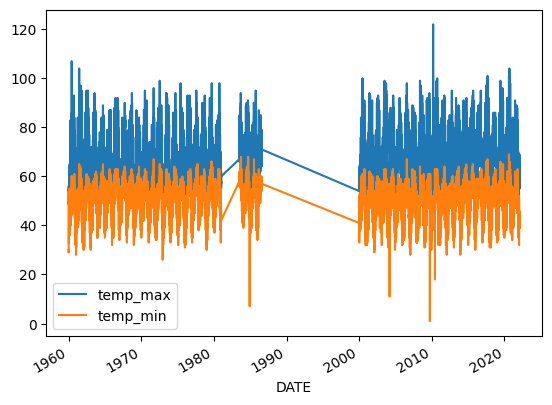

In [71]:
core_weather[['temp_max','temp_min']].plot()

In [76]:
core_weather.index.year.value_counts().sort_index()

DATE
1960    366
1961    365
1962    365
1963    365
1964    366
1965    365
1966    365
1967    365
1968    366
1969    365
1970    365
1971    365
1972    366
1973    365
1974    365
1975    365
1976    366
1977    365
1978    365
1979    365
1980    366
1983    184
1984    366
1985    365
1986    212
2000    365
2001    365
2002    365
2003    365
2004    366
2005    365
2006    365
2007    365
2008    366
2009    365
2010    365
2011    365
2012    365
2013    365
2014    365
2015    365
2016    366
2017    365
2018    365
2019    365
2020    366
2021    364
2022     28
Name: count, dtype: int64

In [83]:
core_weather.groupby(core_weather.index.year).sum()['precip'].sort_values(ascending = False)

DATE
1973    29.37
2005    27.37
1969    25.70
1970    25.31
1967    23.98
1979    23.79
2017    23.34
2012    22.93
2001    22.84
2006    22.79
2010    22.67
1978    22.57
1962    22.47
2000    21.09
2021    20.82
2019    20.00
2016    19.77
2014    19.62
2002    19.12
1963    19.11
1975    17.54
1968    17.19
1974    16.87
1964    16.83
2018    16.82
1965    16.32
1972    16.27
2011    16.06
1984    16.03
2009    14.57
1960    14.01
1961    13.87
2008    13.86
1980    13.58
1966    13.11
2004    12.97
2007    12.79
1977    11.70
2003    11.37
1971    10.61
1976     8.64
2015     8.58
1985     8.50
1983     7.13
2020     6.42
2013     4.89
2022     0.25
1986     0.00
Name: precip, dtype: float64

In [84]:
core_weather['target'] = core_weather.shift(-1)['temp_max']
core_weather

,precip,temp_max,temp_min,target
DATE,,,,
1960-01-01,0.0,49.0,30.0,49.0
1960-01-02,0.0,49.0,29.0,54.0
1960-01-03,0.0,54.0,35.0,54.0
1960-01-04,0.0,54.0,36.0,55.0
1960-01-05,0.0,55.0,33.0,53.0
...,...,...,...,...
2022-01-24,0.0,60.0,39.0,57.0
2022-01-25,0.0,57.0,43.0,57.0
2022-01-26,0.0,57.0,41.0,67.0


In [85]:
core_weather = core_weather.iloc[:-1,:].copy()
core_weather

,precip,temp_max,temp_min,target
DATE,,,,
1960-01-01,0.0,49.0,30.0,49.0
1960-01-02,0.0,49.0,29.0,54.0
1960-01-03,0.0,54.0,35.0,54.0
1960-01-04,0.0,54.0,36.0,55.0
1960-01-05,0.0,55.0,33.0,53.0
...,...,...,...,...
2022-01-23,0.0,60.0,41.0,60.0
2022-01-24,0.0,60.0,39.0,57.0
2022-01-25,0.0,57.0,43.0,57.0


In [86]:
from sklearn.linear_model import Ridge

reg = Ridge(alpha=.1)

In [87]:
predictors = ['precip','temp_max','temp_min']

In [88]:
train = core_weather[:'2020-12-31']
test = core_weather['2021-01-01':]

In [89]:
reg.fit(train[predictors],train['target'])

Ridge(alpha=0.1)

In [90]:
predictions = reg.predict(test[predictors])

In [91]:
from sklearn.metrics import mean_absolute_error

In [105]:
error = mean_absolute_error(test['target'],predictions)

In [95]:
combined = pd.concat([test['target'],pd.Series(predictions, index=test.index)],axis = 1)

In [96]:
combined.columns = ['actual','predictions']
combined

,actual,predictions
DATE,,
2021-01-01,57.0,59.806024
2021-01-02,56.0,59.310181
2021-01-03,62.0,58.538685
2021-01-04,59.0,61.531814
2021-01-05,59.0,59.444266
...,...,...
2022-01-23,60.0,59.985714
2022-01-24,57.0,59.626333
2022-01-25,57.0,58.181680


In [98]:
reg.coef_

array([-2.20730384,  0.72113834,  0.17969047])

In [104]:
coef_summary = pd.Series(reg.coef_, index=predictors)
coef_summary

precip     -2.207304
temp_max    0.721138
temp_min    0.179690
dtype: float64

In [107]:
def create_predictions(predictors,core_weather,reg):
    train = core_weather[:'2020-12-31']
    test = core_weather['2021-01-01':]
    reg.fit(train[predictors],train['target'])
    predictions = reg.predict(test[predictors])
    error = mean_absolute_error(test['target'],predictions)
    combined = pd.concat([test['target'],pd.Series(predictions, index=test.index)],axis = 1)
    combined.columns = ['actual','predictions']
    return error, combined
    

In [111]:
core_weather['month_max'] = core_weather['temp_max'].rolling(window = 30).mean()
core_weather['month_max']

DATE
1960-01-01          NaN
1960-01-02          NaN
1960-01-03          NaN
1960-01-04          NaN
1960-01-05          NaN
                ...    
2022-01-23    56.900000
2022-01-24    57.066667
2022-01-25    57.200000
2022-01-26    57.400000
2022-01-27    57.933333
Name: month_max, Length: 16858, dtype: float64

In [112]:
core_weather['month_day_max'] = core_weather['month_max'] / core_weather['temp_max']
core_weather['max_min'] = core_weather['temp_max'] / core_weather['temp_min']

In [114]:
predictors = ['precip','temp_max','temp_min','month_max','month_day_max','max_min']

In [116]:
core_weather = core_weather.iloc[30:,:].copy()
core_weather

,precip,temp_max,temp_min,target,month_max,month_day_max,max_min
DATE,,,,,,,
1960-01-31,0.00,59.0,46.0,62.0,55.566667,0.941808,1.282609
1960-02-01,0.81,62.0,51.0,59.0,56.000000,0.903226,1.215686
1960-02-02,0.00,59.0,43.0,59.0,56.166667,0.951977,1.372093
1960-02-03,0.20,59.0,47.0,60.0,56.333333,0.954802,1.255319
1960-02-04,0.16,60.0,42.0,60.0,56.500000,0.941667,1.428571
...,...,...,...,...,...,...,...
2022-01-23,0.00,60.0,41.0,60.0,56.900000,0.948333,1.463415
2022-01-24,0.00,60.0,39.0,57.0,57.066667,0.951111,1.538462
2022-01-25,0.00,57.0,43.0,57.0,57.200000,1.003509,1.325581


In [117]:
error, combined = create_predictions(predictors, core_weather, reg)

In [118]:
error

3.3601297462076047

In [120]:
core_weather.index.month

Index([1, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       ...
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
      dtype='int32', name='DATE', length=16828)

In [129]:
core_weather['month_avg'] = core_weather['temp_max'].groupby(core_weather.index.month).transform(lambda x: x.expanding(1).mean())

In [130]:
core_weather['day_of_year_avg'] = core_weather['temp_max'].groupby(core_weather.index.day_of_year).transform(lambda x: x.expanding(1).mean())

In [131]:
core_weather

,precip,temp_max,temp_min,target,month_max,month_day_max,max_min,month_avg,day_of_year_avg
DATE,,,,,,,,,
1960-01-31,0.00,59.0,46.0,62.0,55.566667,0.941808,1.282609,59.000000,59.000000
1960-02-01,0.81,62.0,51.0,59.0,56.000000,0.903226,1.215686,62.000000,62.000000
1960-02-02,0.00,59.0,43.0,59.0,56.166667,0.951977,1.372093,60.500000,59.000000
1960-02-03,0.20,59.0,47.0,60.0,56.333333,0.954802,1.255319,60.000000,59.000000
1960-02-04,0.16,60.0,42.0,60.0,56.500000,0.941667,1.428571,60.000000,60.000000
...,...,...,...,...,...,...,...,...,...
2022-01-23,0.00,60.0,41.0,60.0,56.900000,0.948333,1.463415,56.781536,57.130435
2022-01-24,0.00,60.0,39.0,57.0,57.066667,0.951111,1.538462,56.783803,57.239130
2022-01-25,0.00,57.0,43.0,57.0,57.200000,1.003509,1.325581,56.783955,57.347826


In [134]:
predictors = ['precip','temp_max','temp_min','month_max','month_day_max','max_min','month_avg','day_of_year_avg']

In [135]:
error, combined = create_predictions(predictors, core_weather, reg)

In [136]:
error

3.3176926587659943

In [137]:
reg.coef_

array([ -0.90804013,   0.40146278,   0.03114081,   0.33672074,
       -15.97061869,   0.0493612 ,   0.14343362,   0.08006707])

In [140]:
new_coef_summary = pd.Series(reg.coef_,predictors)
new_coef_summary

precip             -0.908040
temp_max            0.401463
temp_min            0.031141
month_max           0.336721
month_day_max     -15.970619
max_min             0.049361
month_avg           0.143434
day_of_year_avg     0.080067
dtype: float64

In [143]:
core_weather.corr()['target']

precip            -0.205413
temp_max           0.821650
temp_min           0.596016
target             1.000000
month_max          0.686842
month_day_max     -0.421537
max_min            0.045228
month_avg          0.689805
day_of_year_avg    0.712334
Name: target, dtype: float64

In [145]:
combined['diff'] = (combined['actual'] - combined['predictions']).abs()
combined.sort_values('diff',ascending = False).head(15)

,actual,predictions,diff
DATE,,,
2021-01-17,83.0,68.585837,14.414163
2021-05-07,81.0,67.774432,13.225568
2021-04-01,62.0,75.178360,13.178360
2021-02-22,84.0,71.168844,12.831156
2021-10-16,66.0,78.823197,12.823197
2021-02-21,77.0,64.415171,12.584829
2021-03-30,82.0,70.104917,11.895083
2021-06-16,91.0,79.113947,11.886053
2021-07-07,79.0,67.321879,11.678121


### Next Step
1. Predict temperture for next week
2. Combined with different weather stations
3. Try other potential predictors from original data 
4. Try different models